# Group Preprocessing Pipeline
**Group ID:** MLB-WEB3G1-05


## 1. Import libraries and load the original CSV once (Shared)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from pathlib import Path

sns.set_theme(style='whitegrid')

data_path = Path('data/raw/depression_data.csv')
output_path = Path('results/outputs')
viz_path = Path('results/eda_visualizations')
output_path.mkdir(parents=True, exist_ok=True)
viz_path.mkdir(parents=True, exist_ok=True)

# Load the dataset once
try:
    df = pd.read_csv(data_path)
    print('Dataset loaded successfully.')
except FileNotFoundError:
    print('Error: depression_data.csv not found in data/raw/. Please upload it.')
    df = pd.DataFrame() # Empty fallback



Dataset loaded successfully.


## 2. Detect and remove verified duplicate records 


In [2]:
# Load the dataset
# df = pd.read_csv("depression_data.csv")

# Display the first 5 rows
df.head()


,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [3]:
# Display the number of rows and columns
print("Original dataset shape:", df.shape)


Original dataset shape: (413768, 16)


In [4]:
# Check for duplicate rows
duplicate_rows = df[df.duplicated()]

# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


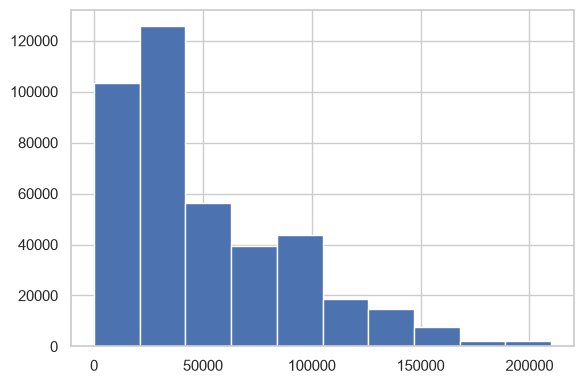

In [5]:
# import seaborn as sns
# import matplotlib.pyplot as plt

df["Income"].hist(figsize=(6, 4))

plt.tight_layout()
plt.show()


In [6]:
# Removing duplicates in-place as per instructions
if not df.empty:
    df.drop_duplicates(inplace=True)
    print('Duplicates removed.')



Duplicates removed.


## 3. Handle missing input values 1

In [7]:
# Import pandas for working with tabular data
# import pandas as pd

# Load the original dataset
# df = pd.read_csv("depression_data.csv")

# Confirm the dataset loaded and preview five records
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (413768, 16)


,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [8]:
# Count missing values in each column
missing_count = df.isna().sum()

# Calculate the percentage missing in each column
missing_percentage = (missing_count / len(df)) * 100

# Combine the results into a summary table
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage.round(2)
})

display(missing_summary)

# Count missing cells across the entire dataset
print("Total missing values:", missing_count.sum())


,Missing Count,Missing Percentage
Name,0,0.0
Age,0,0.0
Marital Status,0,0.0
Education Level,0,0.0
Number of Children,0,0.0
Smoking Status,0,0.0
Physical Activity Level,0,0.0
Employment Status,0,0.0
Income,0,0.0
Alcohol Consumption,0,0.0


Total missing values: 0


In [9]:
# Select text columns
text_columns = df.select_dtypes(include=["object", "string"]).columns

# Possible missing-value markers to investigate
placeholders = ["?", "unknown", "n/a", "na", "null", "none", "nan"]

results = []

for column in text_columns:
    # Standardize text temporarily for checking
    text = df[column].astype("string").str.strip().str.lower()

    results.append({
        "Column": column,
        "Blank Entries": text.eq("").sum(),
        "Possible Placeholders": text.isin(placeholders).sum()
    })

# Display the results
hidden_missing_summary = pd.DataFrame(results)
display(hidden_missing_summary)


,Column,Blank Entries,Possible Placeholders
0,Name,0,0
1,Marital Status,0,0
2,Education Level,0,0
3,Smoking Status,0,0
4,Physical Activity Level,0,0
5,Employment Status,0,0
6,Alcohol Consumption,0,0
7,Dietary Habits,0,0
8,Sleep Patterns,0,0
9,History of Mental Illness,0,0


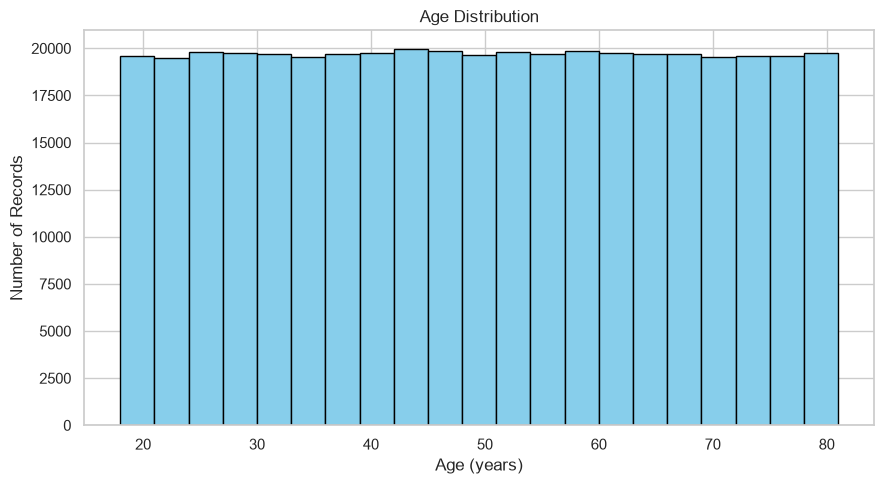

In [10]:
# import matplotlib.pyplot as plt

# Equal-width bins, each covering three whole-number ages
age_bins = list(range(18, 82, 3))

plt.figure(figsize=(9, 5))
plt.hist(
    df["Age"],
    bins=age_bins,
    color="skyblue",
    edgecolor="black"
)

plt.title("Age Distribution")
plt.xlabel("Age (years)")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


## 4. Investigate and handle income outliers with justification 

In [11]:
# Import required libraries
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# Improve the appearance of graphs
sns.set_theme(style="whitegrid")

# Load the dataset
# df = pd.read_csv("D:/user/Documents/New folder/depression_data.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()


Dataset loaded successfully.
Dataset shape: (413768, 16)


,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [12]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numerical_columns)


Numerical columns:
['Age', 'Number of Children', 'Income']


In [13]:
# Statistical summary of numerical variables
numerical_summary = df[numerical_columns].describe().T

display(numerical_summary)


,count,mean,std,min,25%,50%,75%,max
Age,413768.0,49.000713,18.158759,18.00,33.00,49.000,65.0,80.00
Number of Children,413768.0,1.298972,1.237054,0.00,0.00,1.000,2.0,4.00
Income,413768.0,50661.707971,40624.100565,0.41,21001.03,37520.135,76616.3,209995.22


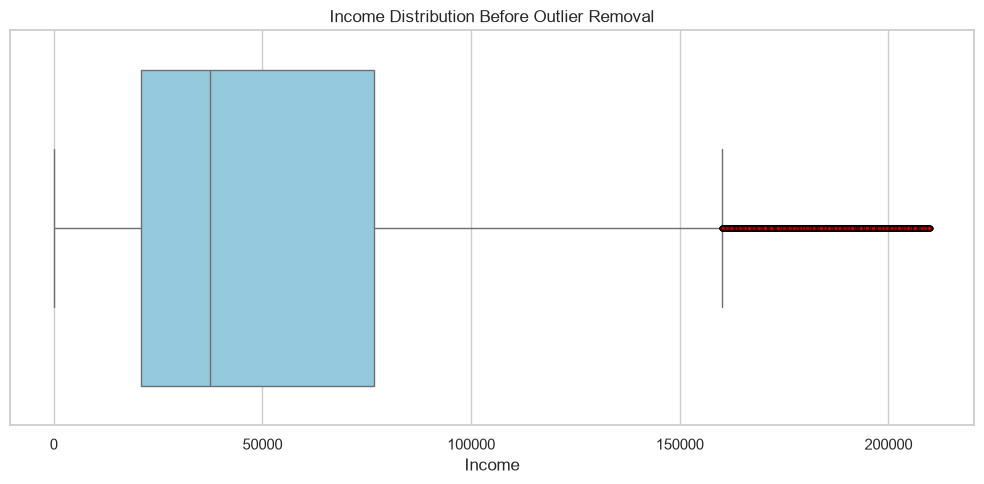

In [14]:
# Create the income boxplot before outlier removal
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["Income"],
    color="skyblue",
    flierprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": 3,
        "alpha": 0.5
    }
)

plt.title("Income Distribution Before Outlier Removal")
plt.xlabel("Income")
plt.tight_layout()
plt.show()


In [15]:
# Calculate the first quartile and third quartile
Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)

# Calculate the Interquartile Range
IQR = Q3 - Q1

# Calculate lower and upper boundaries
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"First Quartile (Q1): {Q1:.2f}")
print(f"Third Quartile (Q3): {Q3:.2f}")
print(f"Interquartile Range: {IQR:.2f}")
print(f"Lower Boundary: {lower_bound:.2f}")
print(f"Upper Boundary: {upper_bound:.2f}")


First Quartile (Q1): 21001.03
Third Quartile (Q3): 76616.30
Interquartile Range: 55615.27
Lower Boundary: -62421.88
Upper Boundary: 160039.21


In [16]:
# Create a Boolean condition for income outliers
income_outlier_mask = (
    (df["Income"] < lower_bound) |
    (df["Income"] > upper_bound)
)

# Extract outlier records
income_outliers = df.loc[income_outlier_mask].copy()

# Calculate outlier information
outlier_count = len(income_outliers)
outlier_percentage = (outlier_count / len(df)) * 100

print("Total income outliers:", outlier_count)
print(f"Outlier percentage: {outlier_percentage:.2f}%")

# Display selected outlier records
income_outliers[["Name", "Age", "Employment Status", "Income"]].head(10)


Total income outliers: 5157
Outlier percentage: 1.25%


,Name,Age,Employment Status,Income
15,Daniel Estrada,38,Employed,202449.17
105,Brandi Gates,53,Employed,169400.38
170,Hunter Sullivan,36,Employed,180084.56
193,Amy Scott,64,Employed,193843.44
319,Alan Garcia,31,Employed,177029.40
328,Mary Henry MD,31,Employed,209894.25
342,Matthew Rogers,61,Employed,209701.03
632,Janice Powell,34,Employed,186628.22
664,David Rowe,72,Employed,198181.05
670,William Holmes,41,Employed,191332.82


In [17]:
# Create an outlier summary for all numerical columns
outlier_summary = []

for column in numerical_columns:
    Q1_column = df[column].quantile(0.25)
    Q3_column = df[column].quantile(0.75)
    IQR_column = Q3_column - Q1_column

    lower_column = Q1_column - (1.5 * IQR_column)
    upper_column = Q3_column + (1.5 * IQR_column)

    outlier_condition = (
        (df[column] < lower_column) |
        (df[column] > upper_column)
    )

    number_of_outliers = outlier_condition.sum()
    percentage = (number_of_outliers / len(df)) * 100

    outlier_summary.append({
        "Column": column,
        "Q1": Q1_column,
        "Q3": Q3_column,
        "IQR": IQR_column,
        "Lower Bound": lower_column,
        "Upper Bound": upper_column,
        "Outlier Count": number_of_outliers,
        "Outlier Percentage": percentage
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(
    outlier_summary_df.round({
        "Q1": 2,
        "Q3": 2,
        "IQR": 2,
        "Lower Bound": 2,
        "Upper Bound": 2,
        "Outlier Percentage": 2
    })
)


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Age,33.00,65.0,32.00,-15.00,113.00,0,0.00
1,Number of Children,0.00,2.0,2.00,-3.00,5.00,0,0.00
2,Income,21001.03,76616.3,55615.27,-62421.88,160039.21,5157,1.25


In [18]:
# Store the original row count
rows_before = len(df)

# Keep only records within the accepted IQR boundaries
df_cleaned = df.loc[
    (df["Income"] >= lower_bound) &
    (df["Income"] <= upper_bound)
].copy()

# Reset the DataFrame index
df_cleaned.reset_index(drop=True, inplace=True)

# Calculate removal information
rows_after = len(df_cleaned)
rows_removed = rows_before - rows_after
percentage_removed = (rows_removed / rows_before) * 100

print("Rows before outlier removal:", rows_before)
print("Rows removed:", rows_removed)
print("Rows after outlier removal:", rows_after)
print(f"Percentage removed: {percentage_removed:.2f}%")


Rows before outlier removal: 413768
Rows removed: 5157
Rows after outlier removal: 408611
Percentage removed: 1.25%


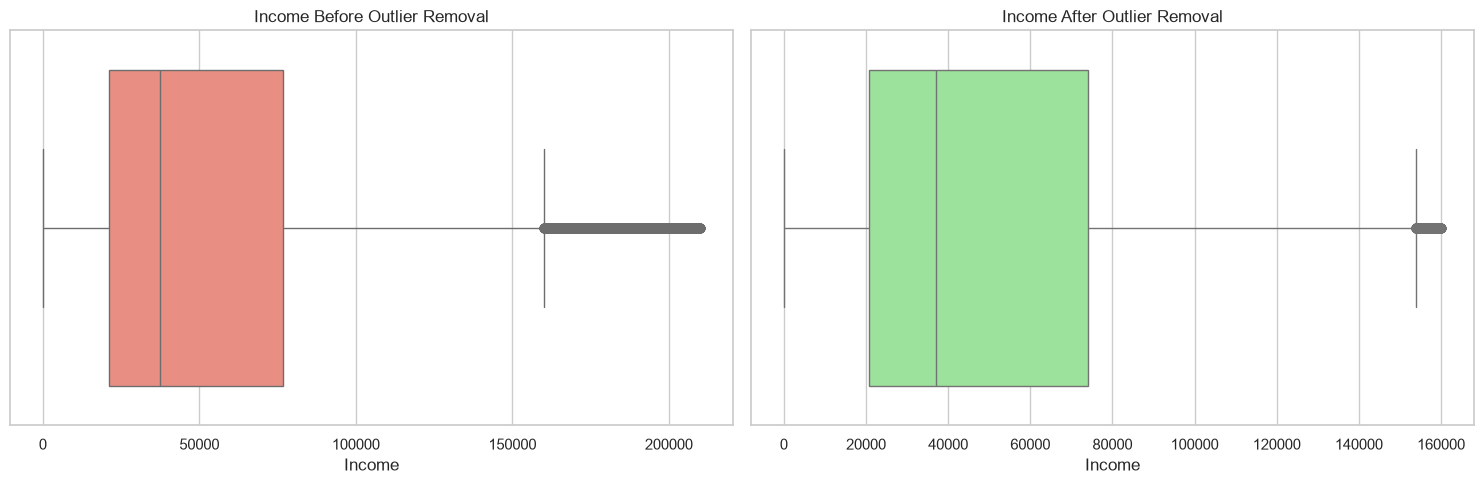

In [19]:
# Create side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before removal
sns.boxplot(
    x=df["Income"],
    color="salmon",
    ax=axes[0]
)
axes[0].set_title("Income Before Outlier Removal")
axes[0].set_xlabel("Income")

# After removal
sns.boxplot(
    x=df_cleaned["Income"],
    color="lightgreen",
    ax=axes[1]
)
axes[1].set_title("Income After Outlier Removal")
axes[1].set_xlabel("Income")

plt.tight_layout()
plt.show()


In [20]:
# Compare income statistics before and after removal
income_comparison = pd.DataFrame({
    "Before Removal": df["Income"].describe(),
    "After Removal": df_cleaned["Income"].describe()
})

display(income_comparison.round(2))


,Before Removal,After Removal
count,413768.00,408611.00
mean,50661.71,48967.61
std,40624.10,37924.58
min,0.41,0.41
25%,21001.03,20742.77
50%,37520.13,37011.40
75%,76616.30,74032.86
max,209995.22,160022.00


In [21]:
# Save the dataset after removing income outliers


print("Cleaned dataset saved successfully.")
print("File name: depression_data_outliers_removed.csv")


Cleaned dataset saved successfully.
File name: depression_data_outliers_removed.csv


## 5. Remove Name and separate input features from the agreed target 


In [22]:
# Member 6: Feature selection
if 'df_cleaned' in locals() and not df_cleaned.empty:
    df_selected = df_cleaned.drop(columns=['Name']).copy()
elif not df.empty:
    df_selected = df.drop(columns=['Name']).copy()
else:
    df_selected = pd.DataFrame()

# Target column
target_column = 'History of Mental Illness' # Group target
if not df_selected.empty and target_column in df_selected.columns:
    X = df_selected.drop(columns=[target_column]).copy()
    y = df_selected[target_column].copy()
    print('Features (X) and Target (y) separated.')



Features (X) and Target (y) separated.


In [23]:
# Import required libraries
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path
# from IPython.display import display

# Improve the appearance of graphs
sns.set_theme(style="whitegrid")

# Set the project folder
project_folder = Path("D:/user/Documents/New folder")

# Load the dataset
# df = pd.read_csv(project_folder / "depression_data.csv")

# Create folders for saving results
viz_path = project_folder / "results" / "eda_visualizations"
output_path = project_folder / "results" / "outputs"

viz_path.mkdir(parents=True, exist_ok=True)
output_path.mkdir(parents=True, exist_ok=True)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()


Dataset loaded successfully.
Dataset shape: (413768, 16)


,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [24]:
# Display column names and data types
column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": df.nunique().values
})

display(column_summary)


,Column,Data Type,Unique Values
0,Name,str,196851
1,Age,int64,63
2,Marital Status,str,4
3,Education Level,str,5
4,Number of Children,int64,5
5,Smoking Status,str,3
6,Physical Activity Level,str,3
7,Employment Status,str,2
8,Income,float64,405282
9,Alcohol Consumption,str,3


In [25]:
# Count the total records and distinct names
total_records = len(df)
unique_names = df["Name"].nunique()
missing_names = df["Name"].isna().sum()

print("Total records:", total_records)
print("Distinct names:", unique_names)
print("Missing names:", missing_names)

# Explain the feature selection decision
print("\nFeature selection decision:")
print("Remove Name because personal names are not justified")
print("input features for the selected prediction task.")
print("Encoding names would introduce many categories.")


Total records: 413768
Distinct names: 196851
Missing names: 0

Feature selection decision:
Remove Name because personal names are not justified
input features for the selected prediction task.
Encoding names would introduce many categories.


In [26]:
# Store the original dataset dimensions
rows_before = df.shape[0]
columns_before = df.shape[1]

# Remove the Name column without changing the original dataset
df_selected = df.drop(columns=["Name"]).copy()

# Store the new dataset dimensions
rows_after = df_selected.shape[0]
columns_after = df_selected.shape[1]

print("Removed column: Name")
print("Columns before feature selection:", columns_before)
print("Columns after feature selection:", columns_after)
print("Rows before feature selection:", rows_before)
print("Rows after feature selection:", rows_after)

df_selected.head()


Removed column: Name
Columns before feature selection: 16
Columns after feature selection: 15
Rows before feature selection: 413768
Rows after feature selection: 413768


,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [27]:
# Create a comparison of dataset dimensions
feature_comparison = pd.DataFrame({
    "Measurement": ["Rows", "Columns"],
    "Before Selection": [rows_before, columns_before],
    "After Selection": [rows_after, columns_after]
})

display(feature_comparison)

# Display the remaining columns
print("\nRemaining columns:")
print(df_selected.columns.tolist())


,Measurement,Before Selection,After Selection
0,Rows,413768,413768
1,Columns,16,15



Remaining columns:
['Age', 'Marital Status', 'Education Level', 'Number of Children', 'Smoking Status', 'Physical Activity Level', 'Employment Status', 'Income', 'Alcohol Consumption', 'Dietary Habits', 'Sleep Patterns', 'History of Mental Illness', 'History of Substance Abuse', 'Family History of Depression', 'Chronic Medical Conditions']


In [28]:
# Set the target column
# Confirm this target with your group
target_column = "History of Mental Illness"

# Separate input features and target
X = df_selected.drop(columns=[target_column]).copy()
y = df_selected[target_column].copy()

print("Target variable:", target_column)
print("Target shape:", y.shape)


Target variable: History of Mental Illness
Target shape: (413768,)


In [29]:
# Set the example target column
target_column = "History of Mental Illness"

# Select the target values
y = df_selected[target_column].copy()

# Keep missing values visible
target_labels = y.astype("string").fillna("(Missing)")

# Calculate category counts and percentages
target_counts = target_labels.value_counts()
target_percentages = (target_counts / len(y)) * 100

# Create the summary table used by the graph
target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

target_summary.index.name = target_column

display(target_summary.round(2))


,Count,Percentage
History of Mental Illness,,
No,287943,69.59
Yes,125825,30.41


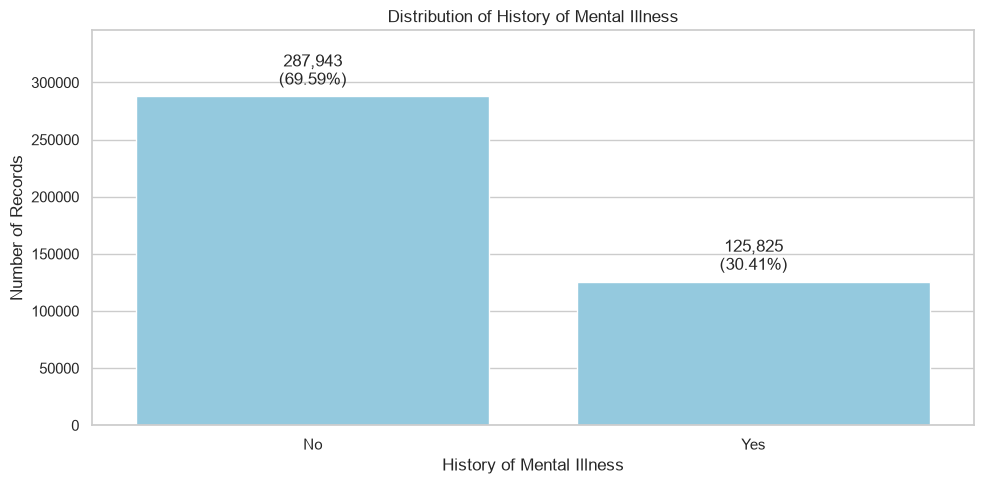

In [30]:
# Create a bar chart of the target categories
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=target_summary.index.astype(str),
    y=target_summary["Count"].to_numpy(),
    color="skyblue"
)

# Display the count and percentage above each bar
for bar, count, percentage in zip(
    ax.patches,
    target_summary["Count"],
    target_summary["Percentage"]
):
    ax.annotate(
        f"{count:,}\n({percentage:.2f}%)",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

plt.title("Distribution of " + target_column)
plt.xlabel(target_column)
plt.ylabel("Number of Records")
plt.ylim(0, target_counts.max() * 1.20)
plt.tight_layout()

# Save the visualization
plt.savefig(
    viz_path / "target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [31]:
# Identify the most common target category
majority_category = target_counts.idxmax()
majority_count = target_counts.max()
majority_percentage = target_percentages.loc[majority_category]

print("Target variable:", target_column)
print("Most common category:", majority_category)
print("Records in this category:", majority_count)
print(f"Percentage: {majority_percentage:.2f}%")

# Explain the distribution
print("\nGraph interpretation:")

for category in target_counts.index:
    print(
        f"{category}: {target_counts[category]:,} records "
        f"({target_percentages[category]:.2f}%)"
    )

print("\nThe chart shows whether target categories")
print("have similar or different numbers of records.")
print("Removing Name does not change these counts.")


Target variable: History of Mental Illness
Most common category: No
Records in this category: 287943
Percentage: 69.59%

Graph interpretation:
No: 287,943 records (69.59%)
Yes: 125,825 records (30.41%)

The chart shows whether target categories
have similar or different numbers of records.
Removing Name does not change these counts.


In [32]:
# Save the dataset after removing Name


# Save the selected input feature names


# Save the target distribution table


print("Results saved successfully.")
print("Dataset and tables:", output_path)
print("Visualization:", viz_path)


Results saved successfully.
Dataset and tables: D:\user\Documents\New folder\results\outputs
Visualization: D:\user\Documents\New folder\results\eda_visualizations


## 6. Encode categorical input features 

In [33]:
# Load the dataset
# df = pd.read_csv("depression_data.csv")

# Display the first 5 rows
df.head()


,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [34]:
# Display the data types of all columns
print(df.dtypes)


Name                                str
Age                               int64
Marital Status                      str
Education Level                     str
Number of Children                int64
Smoking Status                      str
Physical Activity Level             str
Employment Status                   str
Income                          float64
Alcohol Consumption                 str
Dietary Habits                      str
Sleep Patterns                      str
History of Mental Illness           str
History of Substance Abuse          str
Family History of Depression        str
Chronic Medical Conditions          str
dtype: object


In [35]:
# Check Categorical Columns
cat_cols = df.select_dtypes(include='object').columns

print(cat_cols)


Index(['Name', 'Marital Status', 'Education Level', 'Smoking Status',
       'Physical Activity Level', 'Employment Status', 'Alcohol Consumption',
       'Dietary Habits', 'Sleep Patterns', 'History of Mental Illness',
       'History of Substance Abuse', 'Family History of Depression',
       'Chronic Medical Conditions'],
      dtype='str')


C:\Users\user\AppData\Local\Temp\ipykernel_25352\809695974.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [36]:
# create original shape
original_shape = df.shape


In [37]:
# One-Hot Encode Multi-Category Columns
multi_cols = [
    "Marital Status",
    "Education Level",
    "Smoking Status",
    "Physical Activity Level",
    "Employment Status",
    "Alcohol Consumption",
    "Dietary Habits",
    "Sleep Patterns"
]

df = pd.get_dummies(
    df,
    columns=multi_cols,
    drop_first=True
)


In [38]:
# Label Encode Binary Columns
le = LabelEncoder()

binary_cols = [
    "History of Substance Abuse",
    "Family History of Depression",
    "Chronic Medical Conditions",
    "History of Mental Illness"
]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])


In [39]:
# check result
df.head()


,Name,Age,Number of Children,Income,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions,Marital Status_Married,Marital Status_Single,...,Smoking Status_Non-smoker,Physical Activity Level_Moderate,Physical Activity Level_Sedentary,Employment Status_Unemployed,Alcohol Consumption_Low,Alcohol Consumption_Moderate,Dietary Habits_Moderate,Dietary Habits_Unhealthy,Sleep Patterns_Good,Sleep Patterns_Poor
0,Christine Barker,31,2,26265.67,1,0,1,1,True,False,...,True,False,False,True,False,True,True,False,False,False
1,Jacqueline Lewis,55,1,42710.36,1,0,0,1,True,False,...,True,False,True,False,False,False,False,True,False,False
2,Shannon Church,78,1,125332.79,0,0,1,0,False,False,...,True,False,True,False,True,False,False,True,True,False
3,Charles Jordan,58,3,9992.78,0,0,0,0,False,False,...,True,True,False,True,False,True,True,False,False,True
4,Michael Rich,18,0,8595.08,1,0,1,1,False,True,...,True,False,True,True,True,False,True,False,False,False


In [40]:
print("Before:", original_shape)


Before: (413768, 16)


In [41]:
print("After:", df.shape)


After: (413768, 26)


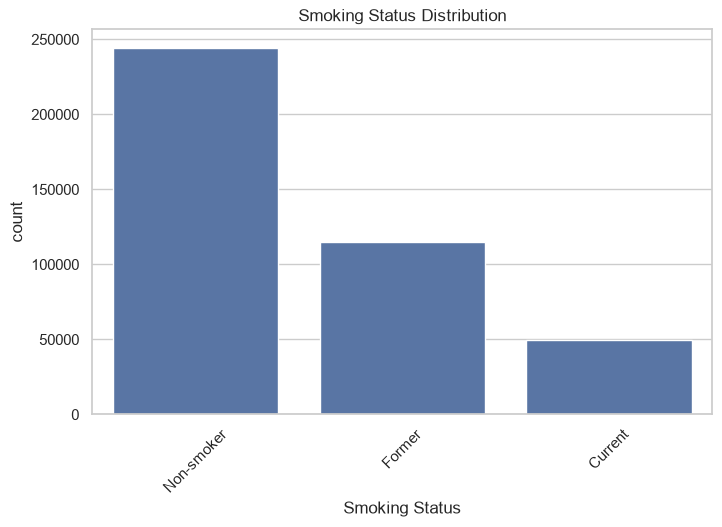

In [42]:
# EDA Graph - Smoking Status Count Plot
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.countplot(x="Smoking Status", data=df_cleaned)
plt.title("Smoking Status Distribution")
plt.xticks(rotation=45)
plt.show()


## 7. Scale the appropriate numerical input features (Member 5)

In [43]:
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
%matplotlib inline

# from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [44]:
df.head()


,Name,Age,Number of Children,Income,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions,Marital Status_Married,Marital Status_Single,...,Smoking Status_Non-smoker,Physical Activity Level_Moderate,Physical Activity Level_Sedentary,Employment Status_Unemployed,Alcohol Consumption_Low,Alcohol Consumption_Moderate,Dietary Habits_Moderate,Dietary Habits_Unhealthy,Sleep Patterns_Good,Sleep Patterns_Poor
0,Christine Barker,31,2,26265.67,1,0,1,1,True,False,...,True,False,False,True,False,True,True,False,False,False
1,Jacqueline Lewis,55,1,42710.36,1,0,0,1,True,False,...,True,False,True,False,False,False,False,True,False,False
2,Shannon Church,78,1,125332.79,0,0,1,0,False,False,...,True,False,True,False,True,False,False,True,True,False
3,Charles Jordan,58,3,9992.78,0,0,0,0,False,False,...,True,True,False,True,False,True,True,False,False,True
4,Michael Rich,18,0,8595.08,1,0,1,1,False,True,...,True,False,True,True,True,False,True,False,False,False


In [45]:
numerical_columns=['Age','Number of Children','Income']
df[numerical_columns].describe()


,Age,Number of Children,Income
count,413768.000000,413768.000000,413768.000000
mean,49.000713,1.298972,50661.707971
std,18.158759,1.237054,40624.100565
min,18.000000,0.000000,0.410000
25%,33.000000,0.000000,21001.030000
50%,49.000000,1.000000,37520.135000
75%,65.000000,2.000000,76616.300000
max,80.000000,4.000000,209995.220000


In [46]:
standard_scaler=StandardScaler()
df_standard=df.copy()

df_standard[numerical_columns]=standard_scaler.fit_transform(df[numerical_columns])
df_standard[numerical_columns].head()


,Age,Number of Children,Income
0,-0.991298,0.566692,-0.600532
1,0.330380,-0.241681,-0.195730
2,1.596988,-0.241681,1.838100
3,0.495590,1.375065,-1.001105
4,-1.707206,-1.050054,-1.035510


In [47]:
minmax_scaler=MinMaxScaler()
df_minmax=df.copy()

df_minmax[numerical_columns]=minmax_scaler.fit_transform(df[numerical_columns])
df_minmax[numerical_columns].head()


,Age,Number of Children,Income
0,0.209677,0.50,0.125076
1,0.596774,0.25,0.203386
2,0.967742,0.25,0.596836
3,0.645161,0.75,0.047584
4,0.000000,0.00,0.040928


In [48]:
comparision=pd.DataFrame({
    'Original Age':df['Age'].head(),
    'Standard Age':df_standard['Age'].head(),
    'MinMax Age':df_minmax['Age'].head()
})
comparision


,Original Age,Standard Age,MinMax Age
0,31,-0.991298,0.209677
1,55,0.330380,0.596774
2,78,1.596988,0.967742
3,58,0.495590,0.645161
4,18,-1.707206,0.000000


In [49]:
corr_df=df[['Age','Number of Children','Income','History of Mental Illness','History of Substance Abuse','Family History of Depression','Chronic Medical Conditions']].copy()

binary_columns=['History of Mental Illness','History of Substance Abuse','Family History of Depression','Chronic Medical Conditions']
for i in binary_columns:
    corr_df[i]=corr_df[i].map({'No':0,'Yes':1})

corr_df.head()


,Age,Number of Children,Income,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,31,2,26265.67,NaN,NaN,NaN,NaN
1,55,1,42710.36,NaN,NaN,NaN,NaN
2,78,1,125332.79,NaN,NaN,NaN,NaN
3,58,3,9992.78,NaN,NaN,NaN,NaN
4,18,0,8595.08,NaN,NaN,NaN,NaN


In [50]:
correlation_matrix=corr_df.corr()
correlation_matrix.round(2)


,Age,Number of Children,Income,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
Age,1.00,0.26,-0.07,NaN,NaN,NaN,NaN
Number of Children,0.26,1.00,0.03,NaN,NaN,NaN,NaN
Income,-0.07,0.03,1.00,NaN,NaN,NaN,NaN
History of Mental Illness,NaN,NaN,NaN,NaN,NaN,NaN,NaN
History of Substance Abuse,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Family History of Depression,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Chronic Medical Conditions,NaN,NaN,NaN,NaN,NaN,NaN,NaN


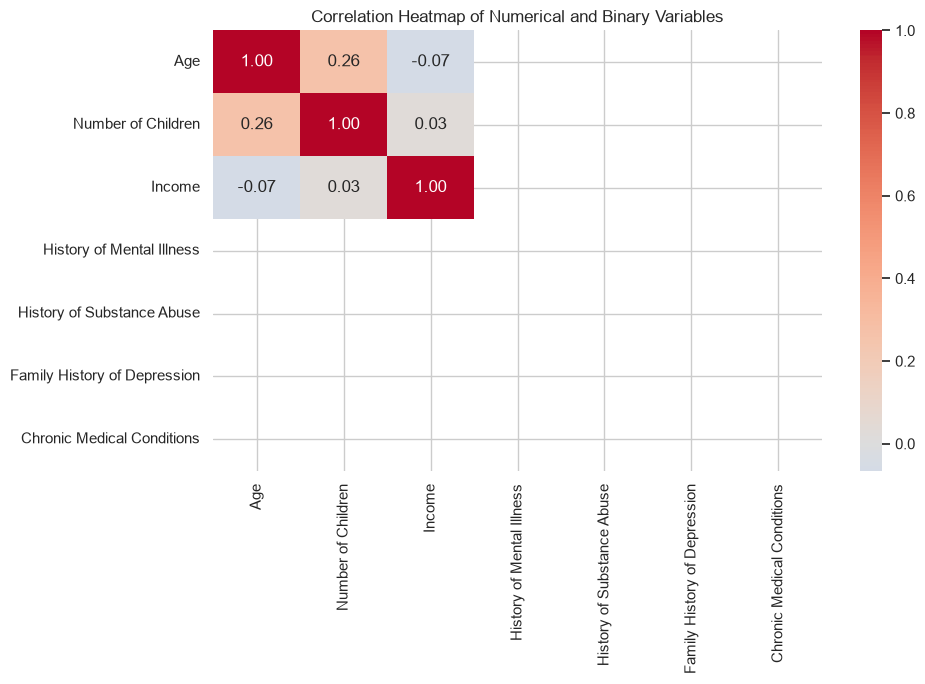

In [51]:
plt.figure(figsize=(10,7))

sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("Correlation Heatmap of Numerical and Binary Variables")
plt.tight_layout()
plt.show()


## 8. Save processed features, target, and visualizations (Shared)

In [52]:
if 'X' in locals() and not X.empty:
    X.to_csv(output_path / 'processed_features.csv', index=False)
    y.to_csv(output_path / 'processed_target.csv', index=False)
    print('Pipeline complete. Files saved to results/outputs/.')



Pipeline complete. Files saved to results/outputs/.
